# A-1 심화: 위험수위 "진입(onset)" 조건부 CSI

A-1 전체 CSI는 대부분 **'이미 위험 유지'** 구간이라 persistence가 강했다. 실무 가치는 **'곧 위험에 진입'**(onset) 예측.
**현재 위험이 아닌 시점(fill[t]<0.8)만 추려**, h분 뒤 위험 진입(fill[t+h]≥0.8)을 맞추는지 평가.
- persistence는 fill[t]<0.8이라 **구조적으로 항상 '아니오'→ CSI=0**(조기경보 불가).
- 비교: ②추세 외삽(fill+h·trend) ③강우 규칙 ④강우+이력 GBM. 모델이 onset에서 유의미한 CSI를 내는지가 관건.

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import sys; sys.path.insert(0,'scripts'); from krfont import set_korean; set_korean()
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
EB="dataset/processed/eda_based/"; THR=0.8; HZ=[1,3,6]
aud=pd.read_parquet(EB+"sewer_danger_audit.parquet")
keep=set(aud.loc[~aud.판정.isin(['stuck_천장','stuck_구간']),'sewer_sensor_id'])
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate'])
sf=sf[sf.sewer_sensor_id.isin(keep)].rename(columns={'sewer_sensor_id':'sid','fill_rate':'fill'})
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
sf=sf.merge(m,left_on='sid',right_on='sensor_id',how='left').merge(r,left_on=['aws_stn','ts10'],right_on=['stn','ts10'],how='left')
sf=sf[sf.rn60m.notna()].sort_values(['sid','ts10'])
reach=sf.groupby('sid').fill.max(); sf=sf[sf.sid.isin(reach[reach>=THR].index)]
g=sf.groupby('sid')
sf['f_l1']=g.fill.shift(1); sf['f_l3']=g.fill.shift(3); sf['trend']=sf.fill-sf['f_l1']
sf['rain_now']=sf.rn60m.fillna(0); sf['rain6h']=sf.rain6h.fillna(0)
sf['hour']=sf.ts10.dt.hour; sf['month']=sf.ts10.dt.month; sf['med_fill']=g.fill.transform('median')
for h in HZ: sf[f'y{h}']=sf.groupby('sid').fill.shift(-h)
F=sf.dropna(subset=['f_l3'])
feat=['fill','f_l1','f_l3','trend','rain_now','rain6h','hour','month','med_fill']
cut=pd.Timestamp('2025-05-01'); tr=F[F.ts10<cut]; te=F[F.ts10>=cut]
print("train",len(tr),"test",len(te))

train 1041596 test 396530


## onset 부분집합(현재 비위험 fill[t]<0.8)에서 진입 예측

In [2]:
def csi(yt,pt):
    TP=int((yt&pt).sum());FP=int((~yt&pt).sum());FN=int((yt&~pt).sum())
    c=TP/(TP+FP+FN) if (TP+FP+FN)>0 else np.nan
    pod=TP/(TP+FN) if (TP+FN)>0 else np.nan
    far=FP/(TP+FP) if (TP+FP)>0 else np.nan
    return c,pod,far,TP,FN
rows=[]
for h in HZ:
    # 현재 비위험만
    trO=tr[tr.fill<THR]; teO=te[te.fill<THR]
    ytrO=(trO[f'y{h}']>=THR).values; yteO=(teO[f'y{h}']>=THR).values
    mtr=trO[f'y{h}'].notna().values; mte=teO[f'y{h}'].notna().values
    npos=int(yteO[mte].sum())
    # ① persistence (항상 False)
    c,pod,far,_,_=csi(yteO[mte],np.zeros(mte.sum(),bool)); rows.append([h*10,'persistence',c,pod,far,npos])
    # ② 추세 외삽
    pred=( (teO['fill']+h*teO['trend']).values>=THR )[mte]; c,pod,far,_,_=csi(yteO[mte],pred); rows.append([h*10,'추세 외삽',c,pod,far,npos])
    # ③ 강우 규칙(train에서 rain6h 임계 CSI최대)
    bx,bc=0,-1
    for x in np.linspace(0,15,31):
        cc,_,_,_,_=csi(ytrO[mtr],(trO['rain6h'].values>=x)[mtr])
        if cc is not None and cc>bc: bc,bx=cc,x
    c,pod,far,_,_=csi(yteO[mte],(teO['rain6h'].values>=bx)[mte]); rows.append([h*10,f'강우규칙(≥{bx:.1f})',c,pod,far,npos])
    # ④ 분류 GBM (train 전체로 학습, onset에서 임계튜닝·평가)
    mtr_all=tr[f'y{h}'].notna().values
    clf=HistGradientBoostingClassifier(max_iter=400,max_depth=7,learning_rate=0.05,class_weight='balanced',random_state=0).fit(tr.loc[mtr_all,feat],(tr[f'y{h}']>=THR).values[mtr_all])
    ptrO=clf.predict_proba(trO[feat])[:,1]; pteO=clf.predict_proba(teO[feat])[:,1]
    bp,bc=0.5,-1
    for pc in np.linspace(0.05,0.95,19):
        cc,_,_,_,_=csi(ytrO[mtr],(ptrO>=pc)[mtr])
        if cc is not None and cc>bc: bc,bp=cc,pc
    c,pod,far,_,_=csi(yteO[mte],(pteO>=bp)[mte]); rows.append([h*10,'강우+이력 GBM',c,pod,far,npos])
R=pd.DataFrame(rows,columns=['horizon','model','CSI','POD','FAR','onset양성']); R.to_parquet(EB+"onset_csi.parquet",index=False)
print(R.pivot(index='horizon',columns='model',values='CSI').round(3).to_string())
print("\nonset 양성(현재 비위험→진입) 수:",R.groupby('horizon')['onset양성'].first().to_dict())

model    persistence  강우+이력 GBM  강우규칙(≥15.0)  추세 외삽
horizon                                            
10               0.0      0.088        0.005  0.086
30               0.0      0.066        0.008  0.054
60               0.0      0.062        0.010  0.042

onset 양성(현재 비위험→진입) 수: {10: 576, 30: 904, 60: 1087}


## POD/FAR 상세 + 시각화

                POD                                      FAR                             
model   persistence 강우+이력 GBM 강우규칙(≥15.0)  추세 외삽 persistence 강우+이력 GBM 강우규칙(≥15.0)  추세 외삽
horizon                                                                                  
10              0.0     0.135       0.201  0.175         NaN     0.800       0.995  0.857
30              0.0     0.090       0.198  0.164         NaN     0.797       0.992  0.926
60              0.0     0.103       0.204  0.174         NaN     0.863       0.990  0.947


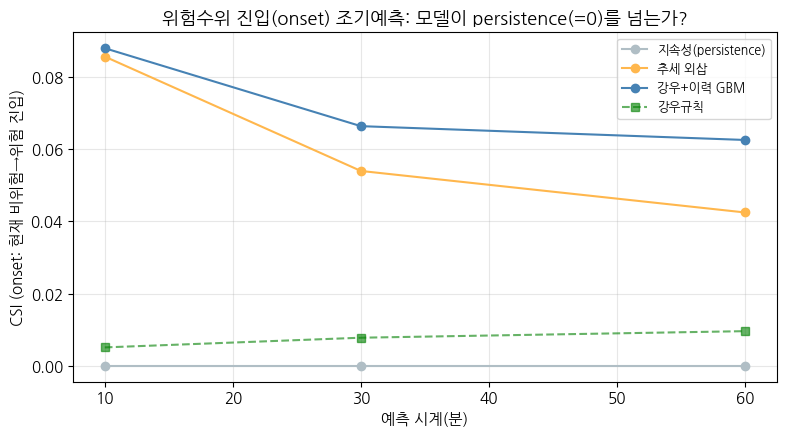

saved


In [3]:
print(R.pivot(index='horizon',columns='model',values=['POD','FAR']).round(3).to_string())
fig,ax=plt.subplots(figsize=(8,4.5))
order=['persistence','추세 외삽','강우+이력 GBM']
col={'persistence':'#b0bec5','추세 외삽':'#ffb74d','강우+이력 GBM':'steelblue'}
for nm in order:
    s=R[R.model==nm]; lab='지속성(persistence)' if nm=='persistence' else nm
    if len(s): ax.plot(s.horizon,s.CSI,'o-',c=col[nm],label=lab)
# 강우규칙은 라벨이 호라이즌마다 달라 별도
rr=R[R.model.str.startswith('강우규칙')]; ax.plot(rr.horizon,rr.CSI,'s--',c='green',alpha=.6,label='강우규칙')
ax.set_xlabel('예측 시계(분)'); ax.set_ylabel('CSI (onset: 현재 비위험→위험 진입)')
ax.set_title('위험수위 진입(onset) 조기예측: 모델이 persistence(=0)를 넘는가?')
ax.legend(fontsize=9); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig('reports/figures_gnn/07_onset_csi.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론
- persistence는 onset에서 CSI=0(구조적). **모델/추세/강우가 0을 의미있게 넘으면 = 현 데이터로도 조기경보 가치 존재.**
- 모델이 추세·강우규칙보다도 높으면 → 비선형 학습의 추가 가치. 레이더로 리드 더 확보 가능.